In [1]:
"""
--->Versions<---
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas: 2.3.3
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
PySpark: 4.0.2
Gdown: 5.2.1
"""

'\n--->Versions<---\nPython: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]\nPandas: 2.3.3\nNumPy: 2.0.2\nMatplotlib: 3.10.0\nSeaborn: 0.13.2\nPySpark: 4.0.2\nGdown: 5.2.1\n'

# 1.Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType,LongType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.classification import FMClassifier, OneVsRest
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import time

# 2.Intial Setup

In [3]:
spark = (SparkSession.builder 
    .appName("HAR_BDA_Mod_2") 
    .config("spark.driver.memory", "8g") 
    .config("spark.sql.shuffle.partitions", "8") 
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 09:53:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.2


In [4]:
#Google Drive folder link
GDRIVE_URL = "https://drive.google.com/drive/folders/1TIjZJ4YOTmQ8l0-GZbQLJP8cf8R2KPKA"

DATASET_DIR = "/kaggle/working/har-dataset"
BASE_PATH = DATASET_DIR

if not os.path.exists(DATASET_DIR):
    print("Downloading dataset from Google Drive...")

    gdown.download_folder(GDRIVE_URL, quiet=False, use_cookies=False)

    print("Download complete!")


else:
    print(f"Dataset already exists at {DATASET_DIR}")

print(f"\nDataset ready at: {BASE_PATH}")

Retrieving folder contents


Processing file 1-lpsAosBf_iLkwN14BCor5y7cq88SRn_ activity_labels.txt
Processing file 1fBf678OLgErrVgohMXuQNRpRQr9aA-2d features_info.txt
Processing file 1RpWYwQtfPbXO4Yq1v2qIAP3siNBKZD15 features.txt
Processing file 1nkAGjTLxF4hGJ1PVfFZbr_NfMD_AmTXP README.txt
Processing file 13xDMhs_YQpE7K6Wxes2XP5g1bDHuycbO subject_test.txt
Processing file 1au6qgTIM4VLkoo4rtbjM8tF6YvTDJ33H subject_train.txt
Processing file 1atQLQC5ijOlzvqM6PeUTVHvmBa-2GmwD X_test.txt
Processing file 13lWHpaCP8Bs9UrjyAGOWhClw7NQMxxdL X_train.txt
Processing file 1kut01iey8L0NgZDirLfesRClXi43jmjT y_test.txt
Processing file 1-pD_UnONJe5acYCSi7O4Rdo8hzJcC2aC y_train.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1-lpsAosBf_iLkwN14BCor5y7cq88SRn_
To: /kaggle/working/har-dataset/activity_labels.txt
100%|██████████| 80.0/80.0 [00:00<00:00, 209kB/s]
Downloading...
From: https://drive.google.com/uc?id=1fBf678OLgErrVgohMXuQNRpRQr9aA-2d
To: /kaggle/working/har-dataset/features_info.txt
100%|██████████| 2.81k/2.81k [00:00<00:00, 2.87MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RpWYwQtfPbXO4Yq1v2qIAP3siNBKZD15
To: /kaggle/working/har-dataset/features.txt
100%|██████████| 15.8k/15.8k [00:00<00:00, 9.78MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nkAGjTLxF4hGJ1PVfFZbr_NfMD_AmTXP
To: /kaggle/working/har-dataset/README.txt
100%|██████████| 6.30k/6.30k [00:00<00:00, 6.21MB/s]
Downloading...
From: https://drive.google.com/uc?id=13xDMhs_YQpE7K6Wxes2XP5g1bDHuycbO
To: /kaggle/working/har-dataset/subject_test.txt
100%|██████████| 

Download complete!

Dataset ready at: /kaggle/working/har-dataset



Download completed


In [5]:
#features.txt has cols name we also extract that and stored in variable
features = pd.read_csv(f"{BASE_PATH}/features.txt",sep=r"\s+", header=None, names=["idx", "name"])
col_names = [f"{name}_{idx}" for idx, name in zip(features["idx"], features["name"])]

In [6]:
#we extracted the data from the X_train.txt & then from y_train.txt. One row in the txt files contain one row of data.
def read_X(path, col_names):
    df = spark.read.text(path)
    df = df.select(
        F.split(F.trim(F.col("value")), r"\s+").alias("vals")
    )
    cols = [
        F.col("vals")[i].cast(DoubleType()).alias(col_names[i])
        for i in range(len(col_names))
    ]
    return df.select(cols)


def read_y(path):
    return spark.read.text(path).select(
        F.trim(F.col("value")).cast(IntegerType()).alias("label")
    )

In [7]:
# we are trying to apply the join for X_train,y_train & laten on X_test,y_test
def add_row_index(df):
    schema = df.schema
    rdd_with_index = df.rdd.zipWithIndex()
    rdd_mapped = rdd_with_index.map(lambda row: row[0] + (row[1],))
    new_schema = schema.add("row_id", LongType(), False)
    return spark.createDataFrame(rdd_mapped, new_schema)

X_train = read_X(f"{BASE_PATH}/X_train.txt", col_names)
y_train = read_y(f"{BASE_PATH}/y_train.txt")

X_train = add_row_index(X_train)
y_train = add_row_index(y_train)

train_df = X_train.join(y_train, on="row_id").drop("row_id")

print(f"Train: {train_df.count()} rows × {len(train_df.columns)} cols")

26/04/17 09:54:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/17 09:54:38 WARN DAGScheduler: Broadcasting large task binary with size 1142.6 KiB


Train: 7352 rows × 562 cols


In [8]:
X_test = read_X(f"{BASE_PATH}/X_test.txt", col_names)
y_test = read_y(f"{BASE_PATH}/y_test.txt")

X_test = add_row_index(X_test)
y_test = add_row_index(y_test)

test_df = X_test.join(y_test, on="row_id").drop("row_id")

print(f"Test : {test_df.count()} rows × {len(test_df.columns)} cols")

26/04/17 09:54:54 WARN DAGScheduler: Broadcasting large task binary with size 1142.2 KiB


Test : 2947 rows × 562 cols


In [9]:
#you can see the first 4 columns with label column & also how many rows each label contains
train_df.select(col_names[:4] + ["label"]).show(5)

train_df.groupBy("label").count().orderBy("label").show()

26/04/17 09:54:58 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


+-------------------+-------------------+-------------------+------------------+-----+
|tBodyAcc-mean()-X_1|tBodyAcc-mean()-Y_2|tBodyAcc-mean()-Z_3|tBodyAcc-std()-X_4|label|
+-------------------+-------------------+-------------------+------------------+-----+
|         0.27965306|       -0.019467156|        -0.11346169|       -0.99537956|    5|
|           0.278457|       -0.020414761|        -0.11273172|       -0.99913488|    5|
|         0.27573444|        -0.01801884|        -0.10677578|       -0.99925496|    5|
|         0.28725164|       -0.037455064|        -0.14597431|       -0.98291504|    4|
|          0.2799976|       -0.019484036|        -0.10572355|       -0.99281839|    4|
+-------------------+-------------------+-------------------+------------------+-----+
only showing top 5 rows


26/04/17 09:55:05 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
26/04/17 09:55:12 WARN DAGScheduler: Broadcasting large task binary with size 1214.5 KiB


+-----+-----+
|label|count|
+-----+-----+
|    1| 1226|
|    2| 1073|
|    3|  986|
|    4| 1286|
|    5| 1374|
|    6| 1407|
+-----+-----+



26/04/17 09:55:12 WARN DAGScheduler: Broadcasting large task binary with size 1217.0 KiB


# 3.Data Analysis

In [10]:
print("Statistics of first 3 features")
stats = train_df.select(col_names[:3] + ["label"]).describe()
stats.show(truncate=True)

Statistics of first 3 features


26/04/17 09:55:12 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


+-------+-------------------+--------------------+--------------------+------------------+
|summary|tBodyAcc-mean()-X_1| tBodyAcc-mean()-Y_2| tBodyAcc-mean()-Z_3|             label|
+-------+-------------------+--------------------+--------------------+------------------+
|  count|               7352|                7352|                7352|              7352|
|   mean|0.27448812496351943|-0.01769542735779...|-0.10914102015124014|3.6433623503808485|
| stddev|0.07026133266614955|0.040810524573263486| 0.05663518808472922|1.7448018716489941|
|    min|               -1.0|                -1.0|                -1.0|                 1|
|    max|                1.0|                 1.0|                 1.0|                 6|
+-------+-------------------+--------------------+--------------------+------------------+



In [11]:
print("Mean of first 3 features grouped by activity")
per_class = train_df.select(col_names[:3]+ ["label"]).groupBy("label").mean().orderBy("label")
per_class.show(truncate=True)

26/04/17 09:55:19 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


Mean of first 3 features grouped by activity


26/04/17 09:55:25 WARN DAGScheduler: Broadcasting large task binary with size 1231.7 KiB


+-----+------------------------+------------------------+------------------------+----------+
|label|avg(tBodyAcc-mean()-X_1)|avg(tBodyAcc-mean()-Y_2)|avg(tBodyAcc-mean()-Z_3)|avg(label)|
+-----+------------------------+------------------------+------------------------+----------+
|    1|     0.27626020087275743|    -0.01776771085111821|    -0.10888408950546494|       1.0|
|    2|     0.26192952725200414|    -0.02664705257359736|    -0.12042356442003724|       2.0|
|    3|     0.28816888847565963|    -0.01637018642175557|    -0.10586032515210761|       3.0|
|    4|      0.2734489988254274|    -0.01214260884597...|    -0.10658074499331255|       4.0|
|    5|      0.2792937570742357|    -0.01612308466366...|    -0.10732962785709045|       5.0|
|    6|     0.26919100708876986|    -0.01834524797718552|    -0.10716870963646057|       6.0|
+-----+------------------------+------------------------+------------------------+----------+



26/04/17 09:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1238.8 KiB


26/04/17 09:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
26/04/17 09:55:32 WARN DAGScheduler: Broadcasting large task binary with size 1214.5 KiB
26/04/17 09:55:32 WARN DAGScheduler: Broadcasting large task binary with size 1217.1 KiB
26/04/17 09:55:32 WARN DAGScheduler: Broadcasting large task binary with size 1217.4 KiB
26/04/17 09:55:32 WARN DAGScheduler: Broadcasting large task binary with size 1216.9 KiB


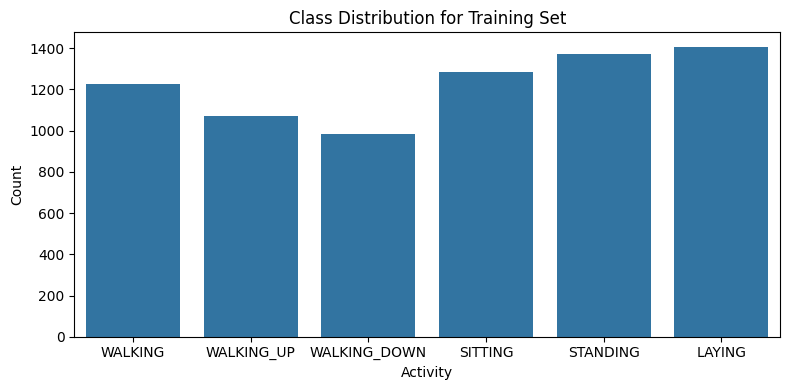

In [12]:
label_dist = train_df.groupBy("label").count().orderBy("label").toPandas()

activity_map = {
    1: "WALKING", 2: "WALKING_UP", 3: "WALKING_DOWN", 4: "SITTING", 5: "STANDING",  6: "LAYING"
}

label_dist["activity"] = label_dist["label"].map(activity_map)

plt.figure(figsize=(8, 4))
sns.barplot(data=label_dist, x="activity", y="count")
plt.title("Class Distribution for Training Set")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

26/04/17 09:55:33 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


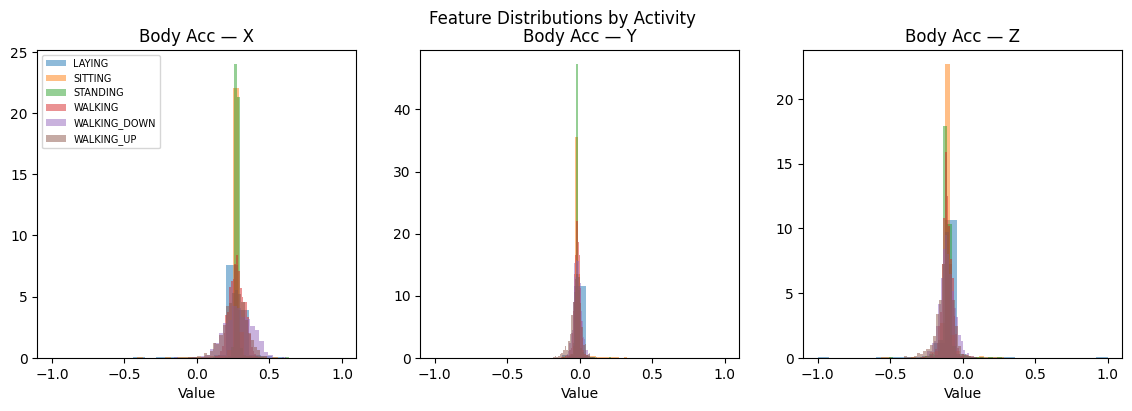

In [13]:
plot_df = train_df.select(col_names[0], col_names[1], col_names[2], "label").toPandas()
plot_df["activity"] = plot_df["label"].map(activity_map)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features_to_plot = [col_names[0], col_names[1], col_names[2]]
titles = ["Body Acc — X", "Body Acc — Y", "Body Acc — Z"]

for ax, feat, title in zip(axes, features_to_plot, titles):
    for activity, group in plot_df.groupby("activity"):
        ax.hist(group[feat], bins=25, alpha=0.5, label=activity, density=True)
    ax.set_title(title)
    ax.set_xlabel("Value")

axes[0].legend(fontsize=7)
plt.suptitle("Feature Distributions by Activity", fontsize=12)
plt.show()

26/04/17 09:55:39 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


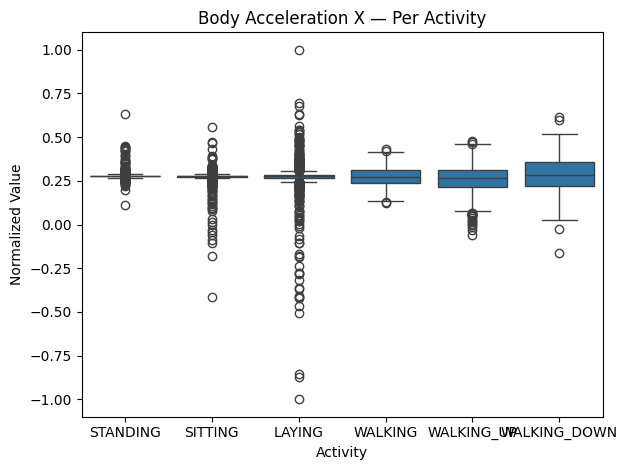

In [14]:
box_df = train_df.select(col_names[0], "label").toPandas()
box_df["activity"] = box_df["label"].map(activity_map)

sns.boxplot(data=box_df, x="activity", y=col_names[0])
plt.title("Body Acceleration X — Per Activity")
plt.xlabel("Activity")
plt.ylabel("Normalized Value")
plt.tight_layout()
plt.show()

# 4.Pre-processing

In [15]:
#We are transforming all features into one column because MLlib requires this

assembler = VectorAssembler(
    inputCols=col_names,
    outputCol="raw_features"
)

train_assembled = assembler.transform(train_df)
test_assembled  = assembler.transform(test_df)

train_assembled.select("raw_features", "label").show(3,truncate=60)

26/04/17 09:55:46 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB
26/04/17 09:55:51 WARN DAGScheduler: Broadcasting large task binary with size 1387.7 KiB


+------------------------------------------------------------+-----+
|                                                raw_features|label|
+------------------------------------------------------------+-----+
|[0.27965306,-0.019467156,-0.11346169,-0.99537956,-0.96718...|    5|
|[0.278457,-0.020414761,-0.11273172,-0.99913488,-0.9846800...|    5|
|[0.27573444,-0.01801884,-0.10677578,-0.99925496,-0.993668...|    5|
+------------------------------------------------------------+-----+
only showing top 3 rows


In [16]:
#Standardscalar is used  to make the feature values mean=0 & standard_deviation=1
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)


scaler_model = scaler.fit(train_assembled)

train_scaled = scaler_model.transform(train_assembled)
test_scaled  = scaler_model.transform(test_assembled)

train_final = train_scaled.select("features", "label")
test_final  = test_scaled.select("features", "label")

print("Train:", train_final.count(), "rows")
print("Test :", test_final.count(), "rows")
train_final.show(3, truncate=60)

26/04/17 09:55:51 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB
26/04/17 09:55:56 WARN DAGScheduler: Broadcasting large task binary with size 1389.8 KiB
26/04/17 09:55:58 WARN DAGScheduler: Broadcasting large task binary with size 1429.3 KiB
26/04/17 09:55:59 WARN DAGScheduler: Broadcasting large task binary with size 1161.2 KiB


Train: 7352 rows


26/04/17 09:56:04 WARN DAGScheduler: Broadcasting large task binary with size 1160.8 KiB


Test : 2947 rows


26/04/17 09:56:07 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB


+------------------------------------------------------------+-----+
|                                                    features|label|
+------------------------------------------------------------+-----+
|[0.07351034830240663,-0.043413522877544346,-0.07628949412...|    5|
|[0.056487329315802116,-0.06663314599948807,-0.06340051071...|    5|
|[0.01773827778647269,-0.007924736219093854,0.041762731461...|    5|
+------------------------------------------------------------+-----+
only showing top 3 rows


26/04/17 09:56:11 WARN DAGScheduler: Broadcasting large task binary with size 1401.7 KiB


In [17]:
#Data is being cached and because it will be used for 3 times once per ML algorithm
train_final.cache()
test_final.cache()
print(train_final.count())
print(test_final.count())

26/04/17 09:56:12 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB
26/04/17 09:56:16 WARN DAGScheduler: Broadcasting large task binary with size 1407.2 KiB
26/04/17 09:56:18 WARN DAGScheduler: Broadcasting large task binary with size 1413.8 KiB
26/04/17 09:56:18 WARN DAGScheduler: Broadcasting large task binary with size 1160.5 KiB


7352


26/04/17 09:56:20 WARN DAGScheduler: Broadcasting large task binary with size 1406.8 KiB
26/04/17 09:56:21 WARN DAGScheduler: Broadcasting large task binary with size 1413.3 KiB


2947


In [18]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# 5.ML Algorithms (Course Project)

# 5.1 Random Forest

In [19]:
start = time.time()

rf = RandomForestClassifier(featuresCol="features", labelCol="label",numTrees=50, maxDepth=10, seed=42)
rf_model = rf.fit(train_final)
rf_time = time.time() - start


rf_preds = rf_model.transform(test_final)
rf_acc = evaluator_acc.evaluate(rf_preds)
rf_f1  = evaluator_f1.evaluate(rf_preds)

print(f"Random Forest — Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | Time: {rf_time:.1f}s")

26/04/17 09:56:22 WARN DAGScheduler: Broadcasting large task binary with size 1422.0 KiB
26/04/17 09:56:22 WARN DAGScheduler: Broadcasting large task binary with size 1434.5 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1434.3 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1442.5 KiB
26/04/17 09:56:29 WARN DAGScheduler: Broadcasting large task binary with size 1591.7 KiB
26/04/17 09:56:30 WARN DAGScheduler: Broadcasting large task binary with size 1617.0 KiB
26/04/17 09:56:31 WARN DAGScheduler: Broadcasting large task binary with size 1662.4 KiB
26/04/17 09:56:32 WARN DAGScheduler: Broadcasting large task binary with size 1750.9 KiB
26/04/17 09:56:33 WARN DAGScheduler: Broadcasting large task binary with size 1911.6 KiB
26/04/17 09:56:34 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/17 09:56:36 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/17 09:56:37 WARN DAGS

Random Forest — Accuracy: 0.9206 | F1: 0.9202 | Time: 23.9s


In [20]:
rf_grid = ParamGridBuilder().addGrid(rf.numTrees, [20, 50, 100]).addGrid(rf.maxDepth, [5, 10]).build()

rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_grid,
    evaluator=evaluator_acc,
    numFolds=3,
    seed=42
)

start = time.time()
rf_cv_model = rf_cv.fit(train_final)
rf_cv_time = time.time() - start

rf_cv_preds = rf_cv_model.transform(test_final)
rf_cv_acc = evaluator_acc.evaluate(rf_cv_preds)
rf_cv_f1  = evaluator_f1.evaluate(rf_cv_preds)

print(f"RF (tuned) — Accuracy: {rf_cv_acc:.4f} | F1: {rf_cv_f1:.4f} | Time: {rf_cv_time:.1f}s")
print(f"Best numTrees : {rf_cv_model.bestModel.getNumTrees}")
print(f"Best maxDepth : {rf_cv_model.bestModel.getMaxDepth()}")

26/04/17 09:56:47 WARN DAGScheduler: Broadcasting large task binary with size 1420.8 KiB
26/04/17 09:56:48 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:56:48 WARN DAGScheduler: Broadcasting large task binary with size 1446.3 KiB
26/04/17 09:56:48 WARN DAGScheduler: Broadcasting large task binary with size 1446.1 KiB
26/04/17 09:56:48 WARN DAGScheduler: Broadcasting large task binary with size 1454.3 KiB
26/04/17 09:56:51 WARN DAGScheduler: Broadcasting large task binary with size 1598.1 KiB
26/04/17 09:56:51 WARN DAGScheduler: Broadcasting large task binary with size 1608.8 KiB
26/04/17 09:56:52 WARN DAGScheduler: Broadcasting large task binary with size 1628.3 KiB
26/04/17 09:56:52 WARN DAGScheduler: Broadcasting large task binary with size 1666.8 KiB
26/04/17 09:56:52 WARN DAGScheduler: Broadcasting large task binary with size 1737.4 KiB
26/04/17 09:56:53 WARN DAGScheduler: Broadcasting large task binary with size 1420.7 KiB
26/04/17 09:56:54 WAR

RF (tuned) — Accuracy: 0.9264 | F1: 0.9261 | Time: 238.0s
Best numTrees : 100
Best maxDepth : 10


# 5.2 Logistic Regression

In [21]:
start = time.time()
lr = LogisticRegression(
    featuresCol="features", labelCol="label",
    maxIter=100, regParam=0.01
)
lr_model = lr.fit(train_final)
lr_time = time.time() - start

lr_preds = lr_model.transform(test_final)
lr_acc = evaluator_acc.evaluate(lr_preds)
lr_f1  = evaluator_f1.evaluate(lr_preds)

print(f"Logistic Regression — Accuracy: {lr_acc:.4f} | F1: {lr_f1:.4f} | Time: {lr_time:.1f}s")

26/04/17 10:00:47 WARN DAGScheduler: Broadcasting large task binary with size 1438.0 KiB
26/04/17 10:00:47 WARN DAGScheduler: Broadcasting large task binary with size 1439.2 KiB
26/04/17 10:00:49 WARN DAGScheduler: Broadcasting large task binary with size 1438.2 KiB
26/04/17 10:00:50 WARN DAGScheduler: Broadcasting large task binary with size 1439.3 KiB
26/04/17 10:00:50 WARN DAGScheduler: Broadcasting large task binary with size 1438.2 KiB
26/04/17 10:00:51 WARN DAGScheduler: Broadcasting large task binary with size 1439.3 KiB
26/04/17 10:00:51 WARN DAGScheduler: Broadcasting large task binary with size 1438.2 KiB
26/04/17 10:00:51 WARN DAGScheduler: Broadcasting large task binary with size 1439.3 KiB
26/04/17 10:00:51 WARN DAGScheduler: Broadcasting large task binary with size 1438.2 KiB
26/04/17 10:00:52 WARN DAGScheduler: Broadcasting large task binary with size 1439.3 KiB
26/04/17 10:00:52 WARN DAGScheduler: Broadcasting large task binary with size 1438.2 KiB
26/04/17 10:00:52 WAR

Logistic Regression — Accuracy: 0.9471 | F1: 0.9472 | Time: 45.8s


In [22]:
lr_grid = ParamGridBuilder().addGrid(lr.regParam,  [0.001, 0.01, 0.1]).addGrid(lr.maxIter,   [50, 100]).build()

lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_grid,
    evaluator=evaluator_acc,
    numFolds=3,
    seed=42
)

start = time.time()
lr_cv_model = lr_cv.fit(train_final)
lr_cv_time = time.time() - start

lr_cv_preds = lr_cv_model.transform(test_final)
lr_cv_acc = evaluator_acc.evaluate(lr_cv_preds)
lr_cv_f1  = evaluator_f1.evaluate(lr_cv_preds)

print(f"LR (tuned) — Accuracy: {lr_cv_acc:.4f} | F1: {lr_cv_f1:.4f} | Time: {lr_cv_time:.1f}s")
print(f"Best regParam : {lr_cv_model.bestModel.getRegParam()}")
print(f"Best maxIter  : {lr_cv_model.bestModel.getMaxIter()}")

26/04/17 10:01:33 WARN DAGScheduler: Broadcasting large task binary with size 1420.8 KiB
26/04/17 10:01:33 WARN DAGScheduler: Broadcasting large task binary with size 1449.8 KiB
26/04/17 10:01:34 WARN DAGScheduler: Broadcasting large task binary with size 1451.0 KiB
26/04/17 10:01:34 WARN DAGScheduler: Broadcasting large task binary with size 1450.0 KiB
26/04/17 10:01:34 WARN DAGScheduler: Broadcasting large task binary with size 1451.1 KiB
26/04/17 10:01:34 WARN DAGScheduler: Broadcasting large task binary with size 1450.0 KiB
26/04/17 10:01:35 WARN DAGScheduler: Broadcasting large task binary with size 1451.1 KiB
26/04/17 10:01:35 WARN DAGScheduler: Broadcasting large task binary with size 1450.0 KiB
26/04/17 10:01:35 WARN DAGScheduler: Broadcasting large task binary with size 1451.1 KiB
26/04/17 10:01:35 WARN DAGScheduler: Broadcasting large task binary with size 1450.0 KiB
26/04/17 10:01:35 WARN DAGScheduler: Broadcasting large task binary with size 1451.1 KiB
26/04/17 10:01:35 WAR

LR (tuned) — Accuracy: 0.9518 | F1: 0.9519 | Time: 580.8s
Best regParam : 0.001
Best maxIter  : 100


# 5.3 Gradient Boost Trees

In [23]:
#GBT algo in Spark only supports binary classification in order to use
#6 classes we can use OnevsRest

start = time.time()
gbt = GBTClassifier(
    featuresCol="features", labelCol="label",
    maxIter=20, maxDepth=5, seed=42
)
gbt_ovr = OneVsRest(classifier=gbt, featuresCol="features", labelCol="label")
gbt_model = gbt_ovr.fit(train_final)
gbt_time = time.time() - start

gbt_preds = gbt_model.transform(test_final)
gbt_acc = evaluator_acc.evaluate(gbt_preds)
gbt_f1  = evaluator_f1.evaluate(gbt_preds)

print(f"GBT (OvR) — Accuracy: {gbt_acc:.4f} | F1: {gbt_f1:.4f} | Time: {gbt_time:.1f}s")

26/04/17 10:11:14 WARN DAGScheduler: Broadcasting large task binary with size 1414.1 KiB
26/04/17 10:11:15 WARN DAGScheduler: Broadcasting large task binary with size 1431.7 KiB
26/04/17 10:11:15 WARN DAGScheduler: Broadcasting large task binary with size 1431.5 KiB
26/04/17 10:11:15 WARN DAGScheduler: Broadcasting large task binary with size 1439.7 KiB
26/04/17 10:11:19 WARN DAGScheduler: Broadcasting large task binary with size 1581.2 KiB
26/04/17 10:11:20 WARN DAGScheduler: Broadcasting large task binary with size 1587.8 KiB
26/04/17 10:11:20 WARN DAGScheduler: Broadcasting large task binary with size 1588.4 KiB
26/04/17 10:11:20 WARN DAGScheduler: Broadcasting large task binary with size 1588.7 KiB
26/04/17 10:11:21 WARN DAGScheduler: Broadcasting large task binary with size 1589.0 KiB
26/04/17 10:11:21 WARN DAGScheduler: Broadcasting large task binary with size 1589.3 KiB
26/04/17 10:11:21 WARN DAGScheduler: Broadcasting large task binary with size 1591.2 KiB
26/04/17 10:11:21 WAR

GBT (OvR) — Accuracy: 0.9046 | F1: 0.9044 | Time: 171.3s


In [24]:
gbt_grid = ParamGridBuilder() \
    .addGrid(gbt.maxIter,  [10, 20]) \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .build()

gbt_cv = CrossValidator(
    estimator=gbt_ovr,
    estimatorParamMaps=gbt_grid,
    evaluator=evaluator_acc,
    numFolds=3,
    seed=42
)

start = time.time()
gbt_cv_model = gbt_cv.fit(train_final)
gbt_cv_time = time.time() - start

gbt_cv_preds = gbt_cv_model.transform(test_final)
gbt_cv_acc = evaluator_acc.evaluate(gbt_cv_preds)
gbt_cv_f1  = evaluator_f1.evaluate(gbt_cv_preds)

print(f"GBT (tuned) — Accuracy: {gbt_cv_acc:.4f} | F1: {gbt_cv_f1:.4f} | Time: {gbt_cv_time:.1f}s")

26/04/17 10:14:28 WARN DAGScheduler: Broadcasting large task binary with size 1420.8 KiB
26/04/17 10:14:28 WARN DAGScheduler: Broadcasting large task binary with size 1425.9 KiB
26/04/17 10:14:28 WARN DAGScheduler: Broadcasting large task binary with size 1443.5 KiB
26/04/17 10:14:28 WARN DAGScheduler: Broadcasting large task binary with size 1443.3 KiB
26/04/17 10:14:29 WARN DAGScheduler: Broadcasting large task binary with size 1451.5 KiB
26/04/17 10:14:31 WARN DAGScheduler: Broadcasting large task binary with size 1592.9 KiB
26/04/17 10:14:32 WARN DAGScheduler: Broadcasting large task binary with size 1599.6 KiB
26/04/17 10:14:32 WARN DAGScheduler: Broadcasting large task binary with size 1600.1 KiB
26/04/17 10:14:32 WARN DAGScheduler: Broadcasting large task binary with size 1600.4 KiB
26/04/17 10:14:32 WARN DAGScheduler: Broadcasting large task binary with size 1602.7 KiB
26/04/17 10:14:32 WARN DAGScheduler: Broadcasting large task binary with size 1603.1 KiB
26/04/17 10:14:33 WAR

GBT (tuned) — Accuracy: 0.9046 | F1: 0.9044 | Time: 1547.5s


In [25]:
results = pd.DataFrame({
    "Algorithm":  ["Random Forest", "Random Forest (tuned)",
                   "Logistic Regression", "Logistic Regression (tuned)",
                   "GBT (OvR)", "GBT (tuned)"],
    "Accuracy":   [rf_acc, rf_cv_acc, lr_acc, lr_cv_acc, gbt_acc, gbt_cv_acc],
    "F1 Score":   [rf_f1,  rf_cv_f1,  lr_f1,  lr_cv_f1,  gbt_f1,  gbt_cv_f1],
    "Time (s)":   [rf_time, rf_cv_time, lr_time, lr_cv_time, gbt_time, gbt_cv_time]
})

results["Accuracy"] = results["Accuracy"].map("{:.4f}".format)
results["F1 Score"] = results["F1 Score"].map("{:.4f}".format)
results["Time (s)"] = results["Time (s)"].map("{:.1f}".format)

print(results.to_string(index=False))

                  Algorithm Accuracy F1 Score Time (s)
              Random Forest   0.9206   0.9202     23.9
      Random Forest (tuned)   0.9264   0.9261    238.0
        Logistic Regression   0.9471   0.9472     45.8
Logistic Regression (tuned)   0.9518   0.9519    580.8
                  GBT (OvR)   0.9046   0.9044    171.3
                GBT (tuned)   0.9046   0.9044   1547.5


In [26]:

course_results = pd.DataFrame({
    "Algorithm": [
        "Random Forest",
        "Random Forest (tuned)",
        "Logistic Regression",
        "Logistic Regression (tuned)",
        "GBT (OvR)",
        "GBT (tuned)",
    ],
    "Accuracy": [
        rf_acc, rf_cv_acc,
        lr_acc, lr_cv_acc,
        gbt_acc, gbt_cv_acc,
    ],
    "F1 Score": [
        rf_f1, rf_cv_f1,
        lr_f1, lr_cv_f1,
        gbt_f1, gbt_cv_f1,
    ],
    "Time (s)": [
        rf_time, rf_cv_time,
        lr_time, lr_cv_time,
        gbt_time, gbt_cv_time,
    ],
})


print("\n===== COURSE PROJECT RESULTS =====\n")
display(course_results.round(4))



===== COURSE PROJECT RESULTS =====



,Algorithm,Accuracy,F1 Score,Time (s)
0,Random Forest,0.9206,0.9202,23.9380
1,Random Forest (tuned),0.9264,0.9261,237.9679
2,Logistic Regression,0.9471,0.9472,45.8259
3,Logistic Regression (tuned),0.9518,0.9519,580.7632
4,GBT (OvR),0.9046,0.9044,171.3294
5,GBT (tuned),0.9046,0.9044,1547.4543


/tmp/ipykernel_55/2840336034.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(course_results["Algorithm"], rotation=35, ha="right")
/tmp/ipykernel_55/2840336034.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(course_results["Algorithm"], rotation=35, ha="right")


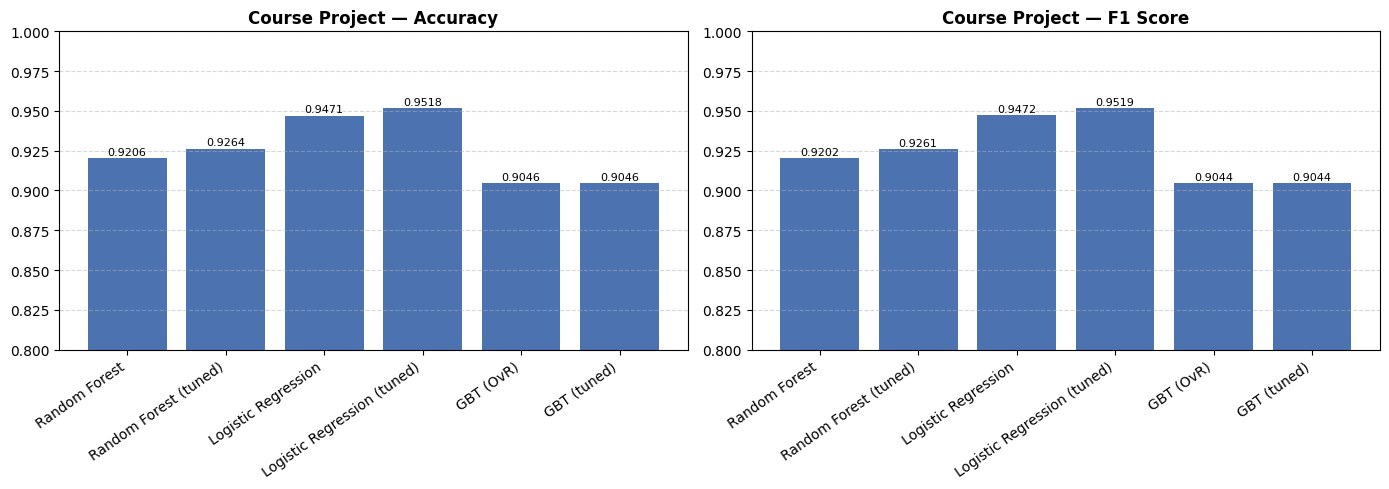

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, metric in zip(axes, ["Accuracy", "F1 Score"]):
    bars = ax.bar(
        course_results["Algorithm"],
        course_results[metric],
        color="#4C72B0"
    )
    
    ax.set_title(f"Course Project — {metric}", fontsize=12, fontweight="bold")
    ax.set_xticklabels(course_results["Algorithm"], rotation=35, ha="right")
    ax.set_ylim(0.80, 1.0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
    for bar, val in zip(bars, course_results[metric]):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+0.002,
            f"{val:.4f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("course_project_metrics.png", dpi=150)
plt.show()